In [2]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import umap

In [44]:
# 1. 実験用データの読み込み（64次元のデータ）
digits = load_digits()
data = digits.data  # 画像データ (1797サンプル × 64特徴量)
target = digits.target  # 正解ラベル (0〜9の数字)

# 2. UMAPのモデルを作成
# 基本はデフォルト設定のままで強力に機能します
n_neighbeors = 3
reducer = umap.UMAP(n_neighbors=n_neighbeors, min_dist=1, random_state=42)

# 3. 64次元のデータを2次元に変換（低次元空間への埋め込み）
embedding = reducer.fit_transform(data)

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Task was destroyed but it is pending!
task: <Task pending name='Task-319' coro=<_async_in_context.<locals>.run_in_context_pre311() done, defined at /usr/local/lib/python3.10/dist-packages/ipykernel/utils.py:76> wait_for=<Task pending name='Task-320' coro=<_async_in_context.<locals>.preserve_context() running at /usr/local/lib/python3.10/dist-packages/ipykernel/utils.py:68> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /usr/local/lib/python3.10/dist-packages/zmq/eventloop/zmqstream.py:563]>
/usr/local/lib/python3.10/dist-packages/numba/core/compiler_machinery.py:393: RuntimeWarning: coroutine '_async_in_context.<locals>.preserve_context' was never awaited
  ret = set()
Task was destroyed but it is pending!
task: <Task pending name='Task-320' coro=<_async_in_context.<locals>.preserve_context()

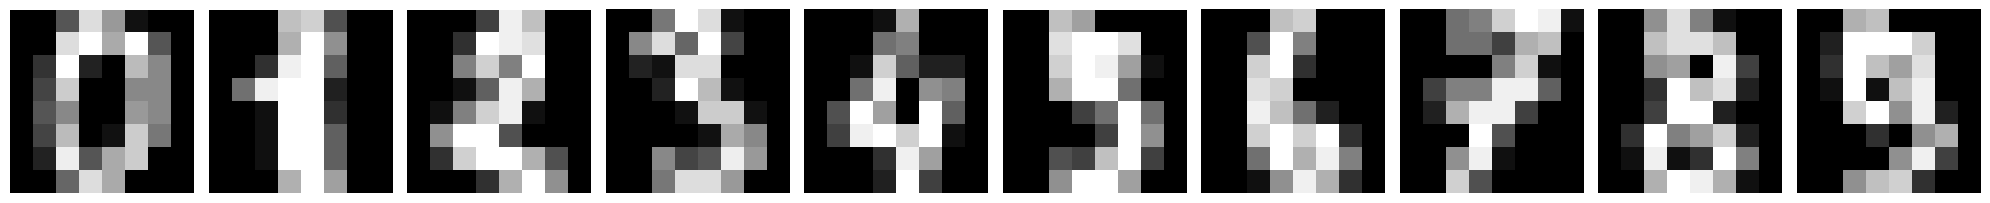

In [45]:
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
flatten = axes.flatten()
for ax, image in zip(flatten, digits.images[:10]):
    ax.imshow(image, cmap="gray")
    ax.axis("off")
plt.tight_layout()
# plt.savefig("Digits_dataset_ex.png")
plt.show()

In [47]:
len(target)

1797

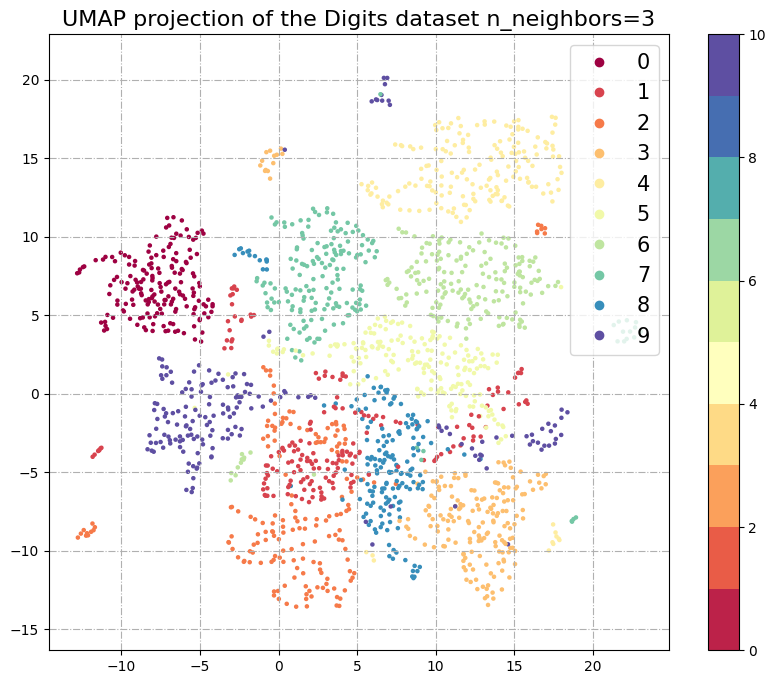

In [49]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(10, 8))
# embedding[:, 0] がX軸、embedding[:, 1] がY軸になります
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=target,
    cmap="Spectral",
    s=5,
)
plt.gca().set_aspect("equal", "datalim")
plt.colorbar(scatter, boundaries=range(11))
plt.title(f"UMAP projection of the Digits dataset n_neighbors={n_neighbeors}", fontsize=16)
handles, _ = scatter.legend_elements()
# 2. 取得したhandlesに対して、表示したい文字列のリストを対応させる
labels = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
plt.legend(handles, labels, loc="upper right", fontsize=15)
plt.grid(ls="dashdot")
plt.savefig("UMAP_Digits_dataset_neighbors_3.png")
plt.show()

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import umap

# 1. 既存データと新規データの準備（例として手書き数字データを使用）
digits = load_digits()
X_old = digits.data[:1500]  # 最初からあるデータ (1500サンプル)
y_old = digits.target[:1500]

X_new = digits.data[1500:]  # 新しく入ってきたデータ (297サンプル)
y_new = digits.target[1500:]

# 2. 既存データだけで UMAP を学習（fit）させる
reducer = umap.UMAP(random_state=42)
embedding_old = reducer.fit_transform(X_old)

# 3. ★新データだけを、既存の空間に変換（transform）する
# （このとき、既存のデータの位置やモデルの構造は一切変わりません）
embedding_new = reducer.transform(X_new)

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


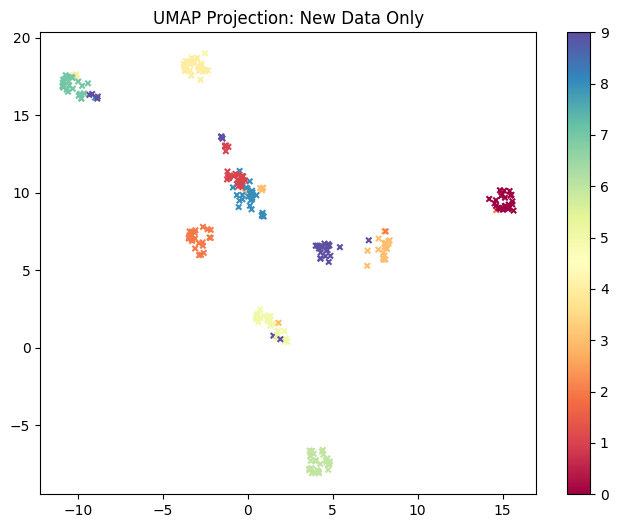

In [11]:
# 4. 新たなデータのみをプロット
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embedding_new[:, 0],
    embedding_new[:, 1],
    c=y_new,
    cmap="Spectral",
    s=15,
    marker="x",  # 新データと分かりやすいように「×」でプロット
)
plt.colorbar(scatter)
plt.title("UMAP Projection: New Data Only")
plt.show()

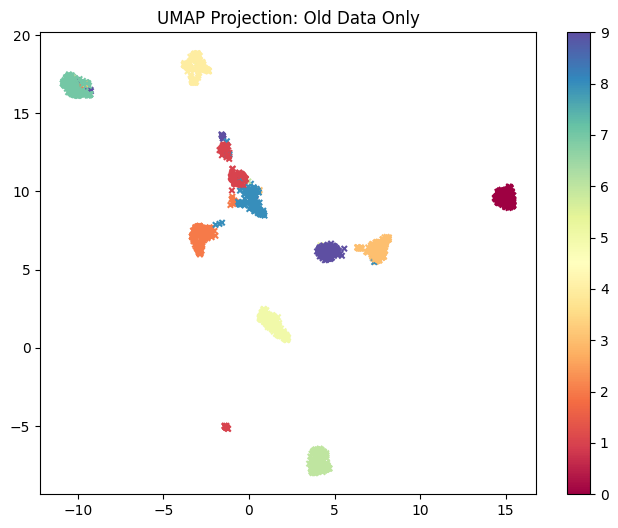

In [12]:
# 4. 新たなデータのみをプロット
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embedding_old[:, 0],
    embedding_old[:, 1],
    c=y_old,
    cmap="Spectral",
    s=15,
    marker="x",  # 新データと分かりやすいように「×」でプロット
)
plt.colorbar(scatter)
plt.title("UMAP Projection: Old Data Only")
plt.show()